#📌 Extracción

In [1]:
# ============================================================
# TELECOM X - Análisis de Evasión de Clientes
# Paso 1: Importar datos desde la API y convertir a DataFrame
# ============================================================

import requests
import pandas as pd
import json

# ── 1. Cargar los datos desde la API ──────────────────────────
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

response = requests.get(url)

# Verificar que la solicitud fue exitosa
if response.status_code == 200:
    print("✅ Datos cargados exitosamente desde la API.")
else:
    print(f"❌ Error al cargar los datos. Código de estado: {response.status_code}")

# ── 2. Convertir el JSON a un objeto Python ───────────────────
data = response.json()

# Exploración inicial del tipo de dato recibido
print(f"\n📦 Tipo de dato recibido: {type(data)}")

# Si es una lista, mostramos cuántos registros hay
if isinstance(data, list):
    print(f"📊 Número de registros: {len(data)}")
    print(f"\n🔍 Primer registro de ejemplo:")
    print(json.dumps(data[0], indent=2, ensure_ascii=False))

# Si es un diccionario, mostramos las claves disponibles
elif isinstance(data, dict):
    print(f"🔑 Claves disponibles: {list(data.keys())}")

# ── 3. Convertir a DataFrame de Pandas ───────────────────────
df = pd.json_normalize(data)

print("\n" + "="*60)
print("📋 INFORMACIÓN DEL DATAFRAME")
print("="*60)

# Dimensiones del DataFrame
print(f"\n📐 Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")

# Primeras filas
print("\n🔎 Primeras 5 filas:")
print(df.head())

# Información general (tipos de datos y valores nulos)
print("\n📊 Información general del DataFrame:")
print(df.info())

# Vista general de columnas disponibles
print("\n📝 Columnas disponibles:")
for col in df.columns:
    print(f"  - {col}")

✅ Datos cargados exitosamente desde la API.

📦 Tipo de dato recibido: <class 'list'>
📊 Número de registros: 7267

🔍 Primer registro de ejemplo:
{
  "customerID": "0002-ORFBO",
  "Churn": "No",
  "customer": {
    "gender": "Female",
    "SeniorCitizen": 0,
    "Partner": "Yes",
    "Dependents": "Yes",
    "tenure": 9
  },
  "phone": {
    "PhoneService": "Yes",
    "MultipleLines": "No"
  },
  "internet": {
    "InternetService": "DSL",
    "OnlineSecurity": "No",
    "OnlineBackup": "Yes",
    "DeviceProtection": "No",
    "TechSupport": "Yes",
    "StreamingTV": "Yes",
    "StreamingMovies": "No"
  },
  "account": {
    "Contract": "One year",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Mailed check",
    "Charges": {
      "Monthly": 65.6,
      "Total": "593.3"
    }
  }
}

📋 INFORMACIÓN DEL DATAFRAME

📐 Dimensiones: 7267 filas x 21 columnas

🔎 Primeras 5 filas:
   customerID Churn customer.gender  customer.SeniorCitizen customer.Partner  \
0  0002-ORFBO    No          Fe

#🔧 Transformación

In [2]:
# ============================================================
# TELECOM X - Análisis de Evasión de Clientes
# Paso 2: Exploración del dataset y diccionario de datos
# ============================================================

import requests
import pandas as pd
import json

# ── Cargar datos (mismo proceso del Paso 1) ───────────────────
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
response = requests.get(url)
data = response.json()
df = pd.json_normalize(data)

print("="*60)
print("📋 PASO 2: EXPLORACIÓN DEL DATASET")
print("="*60)

# ── 1. Dimensiones generales ──────────────────────────────────
print(f"\n📐 Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")

# ── 2. Tipos de datos por columna ─────────────────────────────
print("\n📊 Tipos de datos por columna:")
print(df.dtypes)

# ── 3. Información general ────────────────────────────────────
print("\n📊 Información general (info):")
df.info()

# ── 4. Vista previa de los datos ──────────────────────────────
print("\n🔎 Primeras 5 filas del dataset:")
print(df.head())

# ── 5. Diccionario de datos ───────────────────────────────────
print("\n" + "="*60)
print("📖 DICCIONARIO DE DATOS")
print("="*60)

diccionario = {
    # Identificación
    "customerID":                       "Identificador único del cliente",

    # Datos demográficos
    "customer.gender":                  "Género del cliente (Male / Female)",
    "customer.SeniorCitizen":           "Indica si es adulto mayor (1 = Sí, 0 = No)",
    "customer.Partner":                 "Tiene pareja (Yes / No)",
    "customer.Dependents":              "Tiene dependientes (Yes / No)",

    # Relación con la empresa
    "customer.tenure":                  "Meses que el cliente lleva con la empresa",

    # Servicios contratados - Telefonía
    "phone.PhoneService":               "Tiene servicio telefónico (Yes / No)",
    "phone.MultipleLines":              "Tiene múltiples líneas (Yes / No / No phone service)",

    # Servicios contratados - Internet
    "internet.InternetService":         "Tipo de servicio de internet (DSL / Fiber optic / No)",
    "internet.OnlineSecurity":          "Tiene seguridad en línea (Yes / No / No internet service)",
    "internet.OnlineBackup":            "Tiene respaldo en línea (Yes / No / No internet service)",
    "internet.DeviceProtection":        "Tiene protección de dispositivo (Yes / No / No internet service)",
    "internet.TechSupport":             "Tiene soporte técnico (Yes / No / No internet service)",
    "internet.StreamingTV":             "Tiene streaming de TV (Yes / No / No internet service)",
    "internet.StreamingMovies":         "Tiene streaming de películas (Yes / No / No internet service)",

    # Contrato y facturación
    "account.Contract":                 "Tipo de contrato (Month-to-month / One year / Two year)",
    "account.PaperlessBilling":         "Facturación sin papel (Yes / No)",
    "account.PaymentMethod":            "Método de pago (Electronic check / Mailed check / Bank transfer / Credit card)",
    "account.Charges.Monthly":          "Cargo mensual en dólares",
    "account.Charges.Total":            "Cargo total acumulado en dólares",

    # Variable objetivo
    "Churn":                            "⭐ VARIABLE OBJETIVO: Si el cliente canceló el servicio (Yes / No)",
}

# Mostrar el diccionario de forma organizada
for columna, descripcion in diccionario.items():
    # Verificar si la columna existe en el DataFrame
    existe = "✅" if columna in df.columns else "❓"
    print(f"  {existe} {columna:<40} → {descripcion}")

# ── 6. Columnas más relevantes para el análisis de Churn ──────
print("\n" + "="*60)
print("🎯 COLUMNAS MÁS RELEVANTES PARA EL ANÁLISIS DE EVASIÓN")
print("="*60)

relevantes = {
    "🔴 Variable objetivo":    ["Churn"],
    "📅 Antigüedad":           ["customer.tenure"],
    "💰 Facturación":          ["account.Charges.Monthly", "account.Charges.Total"],
    "📄 Tipo de contrato":     ["account.Contract"],
    "🌐 Tipo de internet":     ["internet.InternetService"],
    "👤 Demografía":           ["customer.SeniorCitizen", "customer.Partner", "customer.Dependents"],
    "📱 Servicios extra":      ["internet.OnlineSecurity", "internet.TechSupport",
                                "internet.StreamingTV", "internet.StreamingMovies"],
    "💳 Método de pago":       ["account.PaymentMethod", "account.PaperlessBilling"],
}

for categoria, columnas in relevantes.items():
    print(f"\n  {categoria}:")
    for col in columnas:
        existe = "✅" if col in df.columns else "❓"
        print(f"    {existe} {col}")

print("\n✅ Exploración completada. Listo para el siguiente paso: limpieza y transformación de datos.")

📋 PASO 2: EXPLORACIÓN DEL DATASET

📐 Dimensiones del dataset: 7267 filas x 21 columnas

📊 Tipos de datos por columna:
customerID                    object
Churn                         object
customer.gender               object
customer.SeniorCitizen         int64
customer.Partner              object
customer.Dependents           object
customer.tenure                int64
phone.PhoneService            object
phone.MultipleLines           object
internet.InternetService      object
internet.OnlineSecurity       object
internet.OnlineBackup         object
internet.DeviceProtection     object
internet.TechSupport          object
internet.StreamingTV          object
internet.StreamingMovies      object
account.Contract              object
account.PaperlessBilling      object
account.PaymentMethod         object
account.Charges.Monthly      float64
account.Charges.Total         object
dtype: object

📊 Información general (info):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entri

In [3]:
# ============================================================
# TELECOM X - Análisis de Evasión de Clientes
# Paso 3: Verificación de calidad de datos (ETL - Transformación)
# ============================================================

import requests
import pandas as pd
import numpy as np
import json

# ── Cargar datos ──────────────────────────────────────────────
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
response = requests.get(url)
data = response.json()
df = pd.json_normalize(data)

print("="*60)
print("🔍 PASO 3: VERIFICACIÓN DE CALIDAD DE DATOS")
print("="*60)
print(f"\n📐 Dataset original: {df.shape[0]} filas x {df.shape[1]} columnas")

# ================================================================
# 1. VALORES AUSENTES (Nulls / NaN)
# ================================================================
print("\n" + "="*60)
print("1️⃣  VALORES AUSENTES")
print("="*60)

nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
resumen_nulos = pd.DataFrame({
    "Valores Nulos": nulos,
    "Porcentaje (%)": nulos_pct
}).query("`Valores Nulos` > 0")

if resumen_nulos.empty:
    print("✅ No se encontraron valores nulos directos.")
else:
    print(resumen_nulos)

# También verificar strings vacíos o espacios en blanco
print("\n🔎 Verificando strings vacíos o solo espacios en blanco:")
cols_objeto = df.select_dtypes(include="object").columns
vacios_encontrados = False
for col in cols_objeto:
    vacios = df[col].astype(str).str.strip().eq("").sum()
    if vacios > 0:
        print(f"  ⚠️  '{col}': {vacios} valores vacíos o en blanco")
        vacios_encontrados = True
if not vacios_encontrados:
    print("  ✅ No se encontraron strings vacíos.")

# Verificar el campo Charges.Total que puede venir como string vacío
print("\n🔎 Verificando columna 'account.Charges.Total' específicamente:")
if "account.Charges.Total" in df.columns:
    sample = df["account.Charges.Total"].head(10)
    print(f"  Tipo actual: {df['account.Charges.Total'].dtype}")
    print(f"  Muestra de valores: {sample.tolist()}")

# ================================================================
# 2. REGISTROS DUPLICADOS
# ================================================================
print("\n" + "="*60)
print("2️⃣  REGISTROS DUPLICADOS")
print("="*60)

duplicados_total = df.duplicated().sum()
print(f"  Filas completamente duplicadas: {duplicados_total}")

if "customerID" in df.columns:
    ids_duplicados = df["customerID"].duplicated().sum()
    print(f"  CustomerIDs duplicados: {ids_duplicados}")
    if ids_duplicados > 0:
        print(df[df["customerID"].duplicated(keep=False)][["customerID"]].head(10))
    else:
        print("  ✅ Todos los customerIDs son únicos.")

# ================================================================
# 3. ERRORES DE FORMATO Y TIPOS DE DATOS
# ================================================================
print("\n" + "="*60)
print("3️⃣  ERRORES DE FORMATO Y TIPOS DE DATOS")
print("="*60)

print("\n  Tipos de datos actuales:")
print(df.dtypes.to_string())

# Verificar columnas numéricas que pueden estar como object
cols_esperadas_numericas = ["account.Charges.Monthly", "account.Charges.Total", "customer.tenure"]
print("\n🔎 Verificando columnas que deberían ser numéricas:")
for col in cols_esperadas_numericas:
    if col in df.columns:
        tipo = df[col].dtype
        icono = "✅" if tipo in ["float64", "int64"] else "⚠️ "
        print(f"  {icono} '{col}': tipo actual = {tipo}")

# ================================================================
# 4. INCONSISTENCIAS EN VARIABLES CATEGÓRICAS
# ================================================================
print("\n" + "="*60)
print("4️⃣  INCONSISTENCIAS EN VARIABLES CATEGÓRICAS")
print("="*60)

cols_categoricas = [
    "customer.gender", "customer.Partner", "customer.Dependents",
    "phone.PhoneService", "phone.MultipleLines",
    "internet.InternetService", "internet.OnlineSecurity",
    "internet.OnlineBackup", "internet.DeviceProtection",
    "internet.TechSupport", "internet.StreamingTV", "internet.StreamingMovies",
    "account.Contract", "account.PaperlessBilling", "account.PaymentMethod",
    "Churn"
]

for col in cols_categoricas:
    if col in df.columns:
        valores = df[col].unique()
        print(f"\n  📌 '{col}':")
        print(f"     Valores únicos ({len(valores)}): {sorted([str(v) for v in valores])}")

# ================================================================
# 5. CORRECCIONES APLICADAS
# ================================================================
print("\n" + "="*60)
print("5️⃣  APLICANDO CORRECCIONES")
print("="*60)

df_clean = df.copy()

# 5.1 Convertir Charges.Total a numérico (puede venir como string vacío)
if "account.Charges.Total" in df_clean.columns:
    df_clean["account.Charges.Total"] = pd.to_numeric(
        df_clean["account.Charges.Total"], errors="coerce"
    )
    nulos_generados = df_clean["account.Charges.Total"].isnull().sum()
    print(f"  🔧 'account.Charges.Total' convertida a numérico. Valores nulos generados: {nulos_generados}")

    # Rellenar nulos con la mediana
    if nulos_generados > 0:
        mediana = df_clean["account.Charges.Total"].median()
        df_clean["account.Charges.Total"].fillna(mediana, inplace=True)
        print(f"     → Nulos rellenados con la mediana: {mediana:.2f}")

# 5.2 Estandarizar strings: quitar espacios y capitalizar
for col in df_clean.select_dtypes(include="object").columns:
    df_clean[col] = df_clean[col].astype(str).str.strip()

print("  🔧 Espacios en blanco eliminados en columnas de texto.")

# 5.3 Convertir columna Churn a binario (1/0) si es texto
if "Churn" in df_clean.columns:
    if df_clean["Churn"].dtype == object:
        df_clean["Churn"] = df_clean["Churn"].map({"Yes": 1, "No": 0})
        print("  🔧 Columna 'Churn' convertida a binario (Yes→1, No→0).")

# 5.4 Eliminar duplicados si los hay
if duplicados_total > 0:
    df_clean.drop_duplicates(inplace=True)
    print(f"  🔧 {duplicados_total} filas duplicadas eliminadas.")
else:
    print("  ✅ No se eliminaron duplicados (no había).")

# ================================================================
# 6. RESUMEN FINAL
# ================================================================
print("\n" + "="*60)
print("📊 RESUMEN FINAL DE CALIDAD")
print("="*60)
print(f"  Filas originales:  {df.shape[0]}")
print(f"  Filas limpias:     {df_clean.shape[0]}")
print(f"  Columnas:          {df_clean.shape[1]}")
print(f"  Nulos restantes:   {df_clean.isnull().sum().sum()}")
print(f"  Duplicados:        {df_clean.duplicated().sum()}")
print("\n✅ Dataset limpio y listo para el análisis exploratorio (EDA).")

# Guardar df_clean para usar en los siguientes pasos
# df_clean.to_csv("telecomx_clean.csv", index=False)

🔍 PASO 3: VERIFICACIÓN DE CALIDAD DE DATOS

📐 Dataset original: 7267 filas x 21 columnas

1️⃣  VALORES AUSENTES
✅ No se encontraron valores nulos directos.

🔎 Verificando strings vacíos o solo espacios en blanco:
  ⚠️  'Churn': 224 valores vacíos o en blanco
  ⚠️  'account.Charges.Total': 11 valores vacíos o en blanco

🔎 Verificando columna 'account.Charges.Total' específicamente:
  Tipo actual: object
  Muestra de valores: ['593.3', '542.4', '280.85', '1237.85', '267.4', '571.45', '7904.25', '5377.8', '340.35', '5957.9']

2️⃣  REGISTROS DUPLICADOS
  Filas completamente duplicadas: 0
  CustomerIDs duplicados: 0
  ✅ Todos los customerIDs son únicos.

3️⃣  ERRORES DE FORMATO Y TIPOS DE DATOS

  Tipos de datos actuales:
customerID                    object
Churn                         object
customer.gender               object
customer.SeniorCitizen         int64
customer.Partner              object
customer.Dependents           object
customer.tenure                int64
phone.PhoneSer

/tmp/ipykernel_646/2232455147.py:140: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean["account.Charges.Total"].fillna(mediana, inplace=True)


#📊 Carga y análisis

In [4]:
# ============================================================
# TELECOM X - Análisis de Evasión de Clientes
# Paso 4: Transformación y limpieza definitiva (ETL - Carga)
# ============================================================

import requests
import pandas as pd
import numpy as np

# ── Cargar datos ──────────────────────────────────────────────
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
response = requests.get(url)
data = response.json()
df = pd.json_normalize(data)

print("="*60)
print("🔧 PASO 4: TRANSFORMACIÓN Y LIMPIEZA DEFINITIVA")
print("="*60)
print(f"\n📐 Dataset inicial: {df.shape[0]} filas x {df.shape[1]} columnas")

df_clean = df.copy()

# ================================================================
# 1. RENOMBRAR COLUMNAS (más legibles y sin puntos)
# ================================================================
print("\n1️⃣  Renombrando columnas...")

df_clean.columns = [col.strip() for col in df_clean.columns]

nuevos_nombres = {
    "customerID":                    "id_cliente",
    "customer.gender":               "genero",
    "customer.SeniorCitizen":        "adulto_mayor",
    "customer.Partner":              "tiene_pareja",
    "customer.Dependents":           "tiene_dependientes",
    "customer.tenure":               "meses_contrato",
    "phone.PhoneService":            "servicio_telefono",
    "phone.MultipleLines":           "multiples_lineas",
    "internet.InternetService":      "tipo_internet",
    "internet.OnlineSecurity":       "seguridad_online",
    "internet.OnlineBackup":         "respaldo_online",
    "internet.DeviceProtection":     "proteccion_dispositivo",
    "internet.TechSupport":          "soporte_tecnico",
    "internet.StreamingTV":          "streaming_tv",
    "internet.StreamingMovies":      "streaming_peliculas",
    "account.Contract":              "tipo_contrato",
    "account.PaperlessBilling":      "factura_digital",
    "account.PaymentMethod":         "metodo_pago",
    "account.Charges.Monthly":       "cargo_mensual",
    "account.Charges.Total":         "cargo_total",
    "Churn":                         "churn",
}

# Solo renombrar las que existen en el DataFrame
nombres_presentes = {k: v for k, v in nuevos_nombres.items() if k in df_clean.columns}
df_clean.rename(columns=nombres_presentes, inplace=True)
print(f"  ✅ {len(nombres_presentes)} columnas renombradas.")

# ================================================================
# 2. ELIMINAR DUPLICADOS
# ================================================================
print("\n2️⃣  Eliminando duplicados...")

antes = df_clean.shape[0]
df_clean.drop_duplicates(inplace=True)
if "id_cliente" in df_clean.columns:
    df_clean.drop_duplicates(subset="id_cliente", inplace=True)
eliminados = antes - df_clean.shape[0]
print(f"  ✅ {eliminados} filas duplicadas eliminadas. Filas restantes: {df_clean.shape[0]}")

# ================================================================
# 3. CORREGIR TIPOS DE DATOS
# ================================================================
print("\n3️⃣  Corrigiendo tipos de datos...")

# cargo_total puede venir como string vacío → convertir a numérico
if "cargo_total" in df_clean.columns:
    df_clean["cargo_total"] = pd.to_numeric(df_clean["cargo_total"], errors="coerce")
    nulos = df_clean["cargo_total"].isnull().sum()
    if nulos > 0:
        mediana = df_clean["cargo_total"].median()
        df_clean["cargo_total"] = df_clean["cargo_total"].fillna(mediana)
        print(f"  🔧 'cargo_total': {nulos} nulos reemplazados con mediana ({mediana:.2f})")
    print(f"  ✅ 'cargo_total' → float64")

# cargo_mensual y meses_contrato también deben ser numéricos
for col in ["cargo_mensual", "meses_contrato"]:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")
        print(f"  ✅ '{col}' → numérico")

# adulto_mayor como booleano/int
if "adulto_mayor" in df_clean.columns:
    df_clean["adulto_mayor"] = df_clean["adulto_mayor"].astype(int)
    print(f"  ✅ 'adulto_mayor' → int (0/1)")

# ================================================================
# 4. ESTANDARIZAR STRINGS
# ================================================================
print("\n4️⃣  Estandarizando valores de texto...")

cols_texto = df_clean.select_dtypes(include="object").columns
for col in cols_texto:
    df_clean[col] = df_clean[col].astype(str).str.strip()

print(f"  ✅ Espacios eliminados en {len(cols_texto)} columnas de texto.")

# ================================================================
# 5. CONVERTIR VARIABLE OBJETIVO CHURN A BINARIO
# ================================================================
print("\n5️⃣  Convirtiendo 'churn' a binario...")

if "churn" in df_clean.columns:
    if df_clean["churn"].dtype == object:
        df_clean["churn"] = df_clean["churn"].map({"Yes": 1, "No": 0})
        print("  ✅ 'churn': Yes → 1 | No → 0")
    else:
        print(f"  ✅ 'churn' ya es numérico (tipo: {df_clean['churn'].dtype})")

# ================================================================
# 6. CREAR COLUMNA DE CARGOS DIARIOS (feature útil para EDA)
# ================================================================
print("\n6️⃣  Creando columna auxiliar 'cargo_diario'...")

if "cargo_mensual" in df_clean.columns:
    df_clean["cargo_diario"] = (df_clean["cargo_mensual"] / 30).round(4)
    print("  ✅ 'cargo_diario' = cargo_mensual / 30")

# ================================================================
# 7. VERIFICACIÓN FINAL
# ================================================================
print("\n" + "="*60)
print("📊 VERIFICACIÓN FINAL DEL DATASET LIMPIO")
print("="*60)

print(f"\n  📐 Dimensiones finales: {df_clean.shape[0]} filas x {df_clean.shape[1]} columnas")

print("\n  📋 Tipos de datos finales:")
print(df_clean.dtypes.to_string())

print("\n  🔎 Nulos por columna:")
nulos_final = df_clean.isnull().sum()
if nulos_final.sum() == 0:
    print("  ✅ Sin valores nulos.")
else:
    print(nulos_final[nulos_final > 0])

print("\n  📊 Estadísticas descriptivas de columnas numéricas:")
print(df_clean.describe().round(2))

print("\n  🎯 Distribución de la variable objetivo 'churn':")
churn_dist = df_clean["churn"].value_counts()
churn_pct  = df_clean["churn"].value_counts(normalize=True).mul(100).round(2)
resumen_churn = pd.DataFrame({"Cantidad": churn_dist, "Porcentaje (%)": churn_pct})
print(resumen_churn)

print("\n  🔎 Primeras 5 filas del dataset limpio:")
print(df_clean.head())

print("\n✅ Dataset completamente limpio y transformado. Listo para el EDA.")

# Exportar dataset limpio
df_clean.to_csv("telecomx_clean.csv", index=False)
print("\n💾 Dataset exportado como 'telecomx_clean.csv'")

🔧 PASO 4: TRANSFORMACIÓN Y LIMPIEZA DEFINITIVA

📐 Dataset inicial: 7267 filas x 21 columnas

1️⃣  Renombrando columnas...
  ✅ 21 columnas renombradas.

2️⃣  Eliminando duplicados...
  ✅ 0 filas duplicadas eliminadas. Filas restantes: 7267

3️⃣  Corrigiendo tipos de datos...
  🔧 'cargo_total': 11 nulos reemplazados con mediana (1391.00)
  ✅ 'cargo_total' → float64
  ✅ 'cargo_mensual' → numérico
  ✅ 'meses_contrato' → numérico
  ✅ 'adulto_mayor' → int (0/1)

4️⃣  Estandarizando valores de texto...
  ✅ Espacios eliminados en 17 columnas de texto.

5️⃣  Convirtiendo 'churn' a binario...
  ✅ 'churn': Yes → 1 | No → 0

6️⃣  Creando columna auxiliar 'cargo_diario'...
  ✅ 'cargo_diario' = cargo_mensual / 30

📊 VERIFICACIÓN FINAL DEL DATASET LIMPIO

  📐 Dimensiones finales: 7267 filas x 22 columnas

  📋 Tipos de datos finales:
id_cliente                 object
churn                     float64
genero                     object
adulto_mayor                int64
tiene_pareja               object


In [5]:
# ============================================================
# TELECOM X - Análisis de Evasión de Clientes
# Paso 5: Crear columna "Cuentas_Diarias"
# ============================================================

import requests
import pandas as pd
import numpy as np

# ── Cargar y limpiar datos (pipeline completo) ────────────────
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
response = requests.get(url)
data = response.json()
df = pd.json_normalize(data)

# Renombrar columnas
nuevos_nombres = {
    "customerID":                    "id_cliente",
    "customer.gender":               "genero",
    "customer.SeniorCitizen":        "adulto_mayor",
    "customer.Partner":              "tiene_pareja",
    "customer.Dependents":           "tiene_dependientes",
    "customer.tenure":               "meses_contrato",
    "phone.PhoneService":            "servicio_telefono",
    "phone.MultipleLines":           "multiples_lineas",
    "internet.InternetService":      "tipo_internet",
    "internet.OnlineSecurity":       "seguridad_online",
    "internet.OnlineBackup":         "respaldo_online",
    "internet.DeviceProtection":     "proteccion_dispositivo",
    "internet.TechSupport":          "soporte_tecnico",
    "internet.StreamingTV":          "streaming_tv",
    "internet.StreamingMovies":      "streaming_peliculas",
    "account.Contract":              "tipo_contrato",
    "account.PaperlessBilling":      "factura_digital",
    "account.PaymentMethod":         "metodo_pago",
    "account.Charges.Monthly":       "cargo_mensual",
    "account.Charges.Total":         "cargo_total",
    "Churn":                         "churn",
}
df_clean = df.rename(columns={k: v for k, v in nuevos_nombres.items() if k in df.columns})

# Limpiar tipos
df_clean["cargo_total"]   = pd.to_numeric(df_clean["cargo_total"], errors="coerce")
df_clean["cargo_mensual"] = pd.to_numeric(df_clean["cargo_mensual"], errors="coerce")
df_clean["cargo_total"]   = df_clean["cargo_total"].fillna(df_clean["cargo_total"].median())
df_clean["churn"]         = df_clean["churn"].map({"Yes": 1, "No": 0})
df_clean.drop_duplicates(inplace=True)

# ================================================================
# CREAR COLUMNA "Cuentas_Diarias"
# ================================================================
print("="*60)
print("📅 PASO 5: CREACIÓN DE COLUMNA 'Cuentas_Diarias'")
print("="*60)

# Cálculo: cargo mensual dividido entre 30 días
df_clean["Cuentas_Diarias"] = (df_clean["cargo_mensual"] / 30).round(4)

print("\n✅ Columna 'Cuentas_Diarias' creada exitosamente.")
print(f"   Fórmula aplicada: cargo_mensual / 30\n")

# ── Verificación ──────────────────────────────────────────────
print("🔎 Verificación de los primeros registros:")
print(df_clean[["id_cliente", "cargo_mensual", "Cuentas_Diarias"]].head(10).to_string(index=False))

# ── Estadísticas descriptivas de la nueva columna ────────────
print("\n📊 Estadísticas descriptivas de 'Cuentas_Diarias':")
stats = df_clean["Cuentas_Diarias"].describe().round(4)
print(f"  Mínimo:   $ {stats['min']}")
print(f"  Máximo:   $ {stats['max']}")
print(f"  Promedio: $ {stats['mean']}")
print(f"  Mediana:  $ {df_clean['Cuentas_Diarias'].median():.4f}")
print(f"  Std Dev:  $ {stats['std']}")

# ── Comparativa: clientes con y sin churn ────────────────────
print("\n📊 Promedio de 'Cuentas_Diarias' por Churn:")
comparativa = df_clean.groupby("churn")["Cuentas_Diarias"].mean().round(4)
comparativa.index = comparativa.index.map({0: "No canceló (0)", 1: "Canceló (1)"})
print(comparativa.to_string())
print("\n💡 Insight: Un cargo diario más alto puede estar asociado a mayor riesgo de evasión.")

print("\n✅ Columna lista. Dataset preparado para el análisis exploratorio (EDA).")

📅 PASO 5: CREACIÓN DE COLUMNA 'Cuentas_Diarias'

✅ Columna 'Cuentas_Diarias' creada exitosamente.
   Fórmula aplicada: cargo_mensual / 30

🔎 Verificación de los primeros registros:
id_cliente  cargo_mensual  Cuentas_Diarias
0002-ORFBO          65.60           2.1867
0003-MKNFE          59.90           1.9967
0004-TLHLJ          73.90           2.4633
0011-IGKFF          98.00           3.2667
0013-EXCHZ          83.90           2.7967
0013-MHZWF          69.40           2.3133
0013-SMEOE         109.70           3.6567
0014-BMAQU          84.65           2.8217
0015-UOCOJ          48.20           1.6067
0016-QLJIS          90.45           3.0150

📊 Estadísticas descriptivas de 'Cuentas_Diarias':
  Mínimo:   $ 0.6083
  Máximo:   $ 3.9583
  Promedio: $ 2.1573
  Mediana:  $ 2.3433
  Std Dev:  $ 1.0043

📊 Promedio de 'Cuentas_Diarias' por Churn:
churn
No canceló (0)    2.0422
Canceló (1)       2.4814

💡 Insight: Un cargo diario más alto puede estar asociado a mayor riesgo de evasión.

✅ Co

In [6]:
# ============================================================
# TELECOM X - Análisis de Evasión de Clientes
# Paso 6: Análisis Descriptivo (EDA - Estadísticas)
# ============================================================

import requests
import pandas as pd
import numpy as np

# ── Cargar y preparar datos (pipeline completo) ───────────────
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
response = requests.get(url)
data = response.json()
df = pd.json_normalize(data)

nuevos_nombres = {
    "customerID":                    "id_cliente",
    "customer.gender":               "genero",
    "customer.SeniorCitizen":        "adulto_mayor",
    "customer.Partner":              "tiene_pareja",
    "customer.Dependents":           "tiene_dependientes",
    "customer.tenure":               "meses_contrato",
    "phone.PhoneService":            "servicio_telefono",
    "phone.MultipleLines":           "multiples_lineas",
    "internet.InternetService":      "tipo_internet",
    "internet.OnlineSecurity":       "seguridad_online",
    "internet.OnlineBackup":         "respaldo_online",
    "internet.DeviceProtection":     "proteccion_dispositivo",
    "internet.TechSupport":          "soporte_tecnico",
    "internet.StreamingTV":          "streaming_tv",
    "internet.StreamingMovies":      "streaming_peliculas",
    "account.Contract":              "tipo_contrato",
    "account.PaperlessBilling":      "factura_digital",
    "account.PaymentMethod":         "metodo_pago",
    "account.Charges.Monthly":       "cargo_mensual",
    "account.Charges.Total":         "cargo_total",
    "Churn":                         "churn",
}
df_clean = df.rename(columns={k: v for k, v in nuevos_nombres.items() if k in df.columns})
df_clean["cargo_total"]      = pd.to_numeric(df_clean["cargo_total"], errors="coerce")
df_clean["cargo_mensual"]    = pd.to_numeric(df_clean["cargo_mensual"], errors="coerce")
df_clean["cargo_total"]      = df_clean["cargo_total"].fillna(df_clean["cargo_total"].median())
df_clean["churn"]            = df_clean["churn"].map({"Yes": 1, "No": 0})
df_clean["Cuentas_Diarias"]  = (df_clean["cargo_mensual"] / 30).round(4)
df_clean.drop_duplicates(inplace=True)

# ================================================================
print("="*60)
print("📊 PASO 6: ANÁLISIS DESCRIPTIVO")
print("="*60)
print(f"\n📐 Dataset: {df_clean.shape[0]} clientes | {df_clean.shape[1]} variables")

# ================================================================
# 1. ESTADÍSTICAS DE VARIABLES NUMÉRICAS
# ================================================================
print("\n" + "="*60)
print("1️⃣  ESTADÍSTICAS DE VARIABLES NUMÉRICAS")
print("="*60)

cols_numericas = ["meses_contrato", "cargo_mensual", "cargo_total", "Cuentas_Diarias"]
cols_num_presentes = [c for c in cols_numericas if c in df_clean.columns]

# Tabla completa de estadísticas
stats = df_clean[cols_num_presentes].agg([
    "count", "mean", "median", "std", "min", "max",
    lambda x: x.quantile(0.25),
    lambda x: x.quantile(0.75),
    lambda x: x.skew(),
    lambda x: x.kurt()
]).rename(index={
    "count":      "Conteo",
    "mean":       "Media",
    "median":     "Mediana",
    "std":        "Desv. Estándar",
    "min":        "Mínimo",
    "max":        "Máximo",
    "<lambda_0>": "Q1 (25%)",
    "<lambda_1>": "Q3 (75%)",
    "<lambda_2>": "Asimetría",
    "<lambda_3>": "Curtosis",
})
print(stats.round(2).to_string())

# Rango intercuartílico (IQR)
print("\n  📌 Rango Intercuartílico (IQR = Q3 - Q1):")
for col in cols_num_presentes:
    q1  = df_clean[col].quantile(0.25)
    q3  = df_clean[col].quantile(0.75)
    iqr = q3 - q1
    print(f"    {col:<22} → IQR = {iqr:.2f}  (Q1={q1:.2f} | Q3={q3:.2f})")

# ================================================================
# 2. TASA GENERAL DE CHURN
# ================================================================
print("\n" + "="*60)
print("2️⃣  TASA GENERAL DE CHURN")
print("="*60)

total      = len(df_clean)
cancelaron = df_clean["churn"].sum()
no_cancel  = total - cancelaron
tasa       = (cancelaron / total * 100).round(2)

print(f"\n  Total de clientes:       {total:>6}")
print(f"  Clientes que cancelaron: {cancelaron:>6}  ({tasa}%)")
print(f"  Clientes que se quedaron:{no_cancel:>6}  ({100 - tasa}%)")

# ================================================================
# 3. ESTADÍSTICAS POR GRUPO CHURN vs NO CHURN
# ================================================================
print("\n" + "="*60)
print("3️⃣  COMPARATIVA NUMÉRICA: CHURN vs NO CHURN")
print("="*60)

comparativa = df_clean.groupby("churn")[cols_num_presentes].agg(["mean", "median", "std"]).round(2)
comparativa.index = comparativa.index.map({0: "No canceló", 1: "Canceló"})
print(comparativa.to_string())

# ================================================================
# 4. ESTADÍSTICAS DE VARIABLES CATEGÓRICAS
# ================================================================
print("\n" + "="*60)
print("4️⃣  DISTRIBUCIÓN DE VARIABLES CATEGÓRICAS")
print("="*60)

cols_categoricas = [
    "genero", "tiene_pareja", "tiene_dependientes", "adulto_mayor",
    "tipo_contrato", "tipo_internet", "metodo_pago", "factura_digital",
    "servicio_telefono"
]

for col in cols_categoricas:
    if col not in df_clean.columns:
        continue
    print(f"\n  📌 {col}:")
    freq  = df_clean[col].value_counts()
    pct   = df_clean[col].value_counts(normalize=True).mul(100).round(2)
    tabla = pd.DataFrame({"Cantidad": freq, "Porcentaje (%)": pct})
    print(tabla.to_string())

# ================================================================
# 5. CORRELACIÓN ENTRE VARIABLES NUMÉRICAS
# ================================================================
print("\n" + "="*60)
print("5️⃣  MATRIZ DE CORRELACIÓN (variables numéricas + churn)")
print("="*60)

cols_corr = cols_num_presentes + ["churn", "adulto_mayor"]
cols_corr = [c for c in cols_corr if c in df_clean.columns]

corr_matrix = df_clean[cols_corr].corr().round(3)
print(corr_matrix.to_string())

print("\n  💡 Correlaciones más fuertes con 'churn':")
corr_churn = corr_matrix["churn"].drop("churn").sort_values(key=abs, ascending=False)
for var, val in corr_churn.items():
    fuerza = "🔴 Fuerte" if abs(val) > 0.3 else "🟡 Moderada" if abs(val) > 0.15 else "⚪ Débil"
    print(f"    {var:<25} r = {val:>7.3f}  {fuerza}")

# ================================================================
# 6. RESUMEN EJECUTIVO
# ================================================================
print("\n" + "="*60)
print("📝 RESUMEN EJECUTIVO")
print("="*60)

media_mensual_churn   = df_clean[df_clean["churn"]==1]["cargo_mensual"].mean()
media_mensual_nochurn = df_clean[df_clean["churn"]==0]["cargo_mensual"].mean()
media_meses_churn     = df_clean[df_clean["churn"]==1]["meses_contrato"].mean()
media_meses_nochurn   = df_clean[df_clean["churn"]==0]["meses_contrato"].mean()

print(f"""
  • Tasa de evasión:         {tasa}% de los clientes cancelaron el servicio.
  • Cargo mensual promedio:
      - Clientes que cancelaron:    $ {media_mensual_churn:.2f}
      - Clientes que se quedaron:   $ {media_mensual_nochurn:.2f}
  • Antigüedad promedio (meses):
      - Clientes que cancelaron:    {media_meses_churn:.1f} meses
      - Clientes que se quedaron:   {media_meses_nochurn:.1f} meses
  • Hallazgo clave: los clientes que cancelan tienden a pagar
    más por mes y llevan menos tiempo con la empresa.
""")

print("✅ Análisis descriptivo completo. Listo para visualizaciones.")

📊 PASO 6: ANÁLISIS DESCRIPTIVO

📐 Dataset: 7267 clientes | 22 variables

1️⃣  ESTADÍSTICAS DE VARIABLES NUMÉRICAS
                meses_contrato  cargo_mensual  cargo_total  Cuentas_Diarias
Conteo                 7267.00        7267.00      7267.00          7267.00
Media                    32.35          64.72      2279.29             2.16
Mediana                  29.00          70.30      1391.00             2.34
Desv. Estándar           24.57          30.13      2267.18             1.00
Mínimo                    0.00          18.25        18.80             0.61
Máximo                   72.00         118.75      8684.80             3.96
<lambda>                  9.00          35.42       401.40             1.18
<lambda>                 55.00          89.88      3778.52             3.00
<lambda>                  0.24          -0.22         0.97            -0.22
<lambda>                 -1.39          -1.26        -0.23            -1.26

  📌 Rango Intercuartílico (IQR = Q3 - Q1):
    me

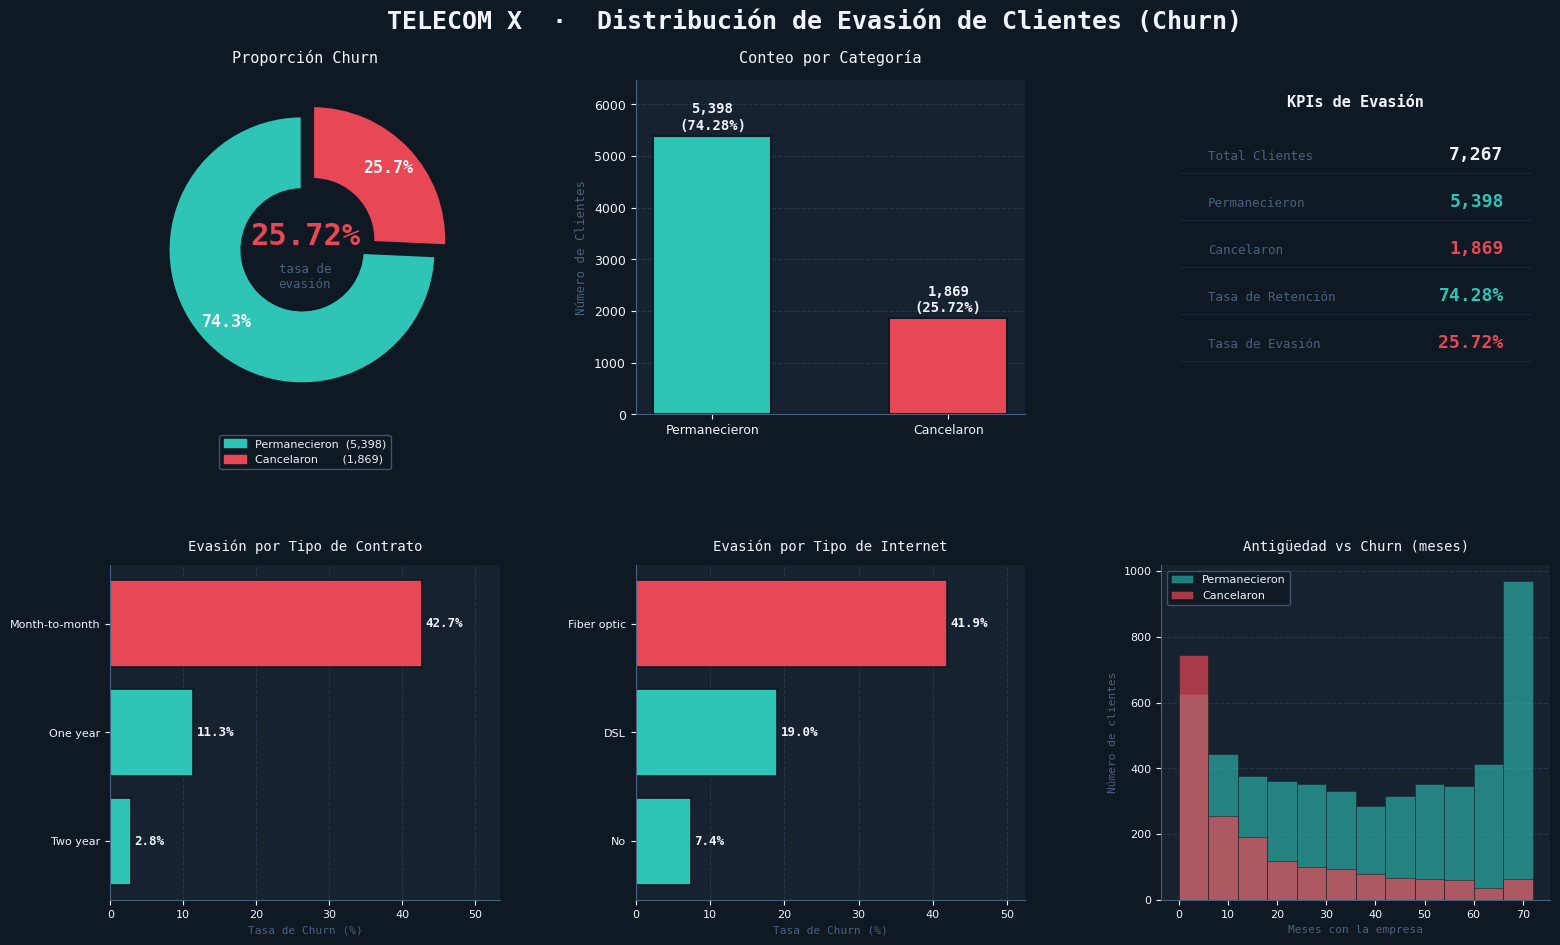


✅ Gráfico guardado como 'telecomx_churn_distribucion.png'


In [9]:
# ============================================================
# TELECOM X - Análisis de Evasión de Clientes
# Paso 7: Visualización de la distribución de Churn
# ============================================================

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import seaborn as sns

# ── Cargar y preparar datos ───────────────────────────────────
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
response = requests.get(url)
data = response.json()
df = pd.json_normalize(data)

nuevos_nombres = {
    "customerID":               "id_cliente",
    "customer.gender":          "genero",
    "customer.SeniorCitizen":   "adulto_mayor",
    "customer.Partner":         "tiene_pareja",
    "customer.Dependents":      "tiene_dependientes",
    "customer.tenure":          "meses_contrato",
    "phone.PhoneService":       "servicio_telefono",
    "phone.MultipleLines":      "multiples_lineas",
    "internet.InternetService": "tipo_internet",
    "internet.OnlineSecurity":  "seguridad_online",
    "internet.OnlineBackup":    "respaldo_online",
    "internet.DeviceProtection":"proteccion_dispositivo",
    "internet.TechSupport":     "soporte_tecnico",
    "internet.StreamingTV":     "streaming_tv",
    "internet.StreamingMovies": "streaming_peliculas",
    "account.Contract":         "tipo_contrato",
    "account.PaperlessBilling": "factura_digital",
    "account.PaymentMethod":    "metodo_pago",
    "account.Charges.Monthly":  "cargo_mensual",
    "account.Charges.Total":    "cargo_total",
    "Churn":                    "churn",
}
df_clean = df.rename(columns={k: v for k, v in nuevos_nombres.items() if k in df.columns})
df_clean["cargo_total"]     = pd.to_numeric(df_clean["cargo_total"], errors="coerce")
df_clean["cargo_mensual"]   = pd.to_numeric(df_clean["cargo_mensual"], errors="coerce")
df_clean["cargo_total"]     = df_clean["cargo_total"].fillna(df_clean["cargo_total"].median())
df_clean["churn"]           = df_clean["churn"].map({"Yes": 1, "No": 0})
df_clean["Cuentas_Diarias"] = (df_clean["cargo_mensual"] / 30).round(4)
df_clean.drop_duplicates(inplace=True)

# ── Métricas base ─────────────────────────────────────────────
total      = len(df_clean)
cancelaron = int(df_clean["churn"].sum())
no_cancel  = total - cancelaron
tasa_churn = round(cancelaron / total * 100, 2)
tasa_ret   = round(no_cancel  / total * 100, 2)

# ── Paleta de colores ─────────────────────────────────────────
COLOR_STAY   = "#2EC4B6"   # teal  → se quedaron
COLOR_CHURN  = "#E84855"   # rojo  → cancelaron
COLOR_BG     = "#0F1923"   # fondo oscuro
COLOR_PANEL  = "#162230"   # panel
COLOR_TEXT   = "#F0F4F8"   # texto claro
COLOR_SUBTLE = "#4A6080"   # texto secundario

# ================================================================
# FIGURA PRINCIPAL
# ================================================================
fig = plt.figure(figsize=(16, 10), facecolor=COLOR_BG)
fig.suptitle(
    "TELECOM X  ·  Distribución de Evasión de Clientes (Churn)",
    fontsize=18, fontweight="bold", color=COLOR_TEXT,
    fontfamily="monospace", y=0.97
)

gs = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35,
              left=0.06, right=0.96, top=0.90, bottom=0.08)

# ── Subgráfico 1: Gráfico de Dona ────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor(COLOR_PANEL)

sizes  = [no_cancel, cancelaron]
colors = [COLOR_STAY, COLOR_CHURN]
explode = (0.03, 0.08)

wedges, texts, autotexts = ax1.pie(
    sizes,
    explode=explode,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.55, edgecolor=COLOR_BG, linewidth=2),
    textprops=dict(color=COLOR_TEXT, fontsize=11, fontfamily="monospace"),
    pctdistance=0.78
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight("bold")

# Texto central
ax1.text(0, 0.08, f"{tasa_churn}%", ha="center", va="center",
         fontsize=22, fontweight="bold", color=COLOR_CHURN,
         fontfamily="monospace")
ax1.text(0, -0.22, "tasa de\nevasión", ha="center", va="center",
         fontsize=9, color=COLOR_SUBTLE, fontfamily="monospace")

ax1.set_title("Proporción Churn", color=COLOR_TEXT,
              fontsize=11, fontfamily="monospace", pad=12)
legend_elements = [
    mpatches.Patch(color=COLOR_STAY,  label=f"Permanecieron  ({no_cancel:,})"),
    mpatches.Patch(color=COLOR_CHURN, label=f"Cancelaron       ({cancelaron:,})"),
]
ax1.legend(handles=legend_elements, loc="lower center",
           bbox_to_anchor=(0.5, -0.18), fontsize=8,
           facecolor=COLOR_BG, edgecolor=COLOR_SUBTLE,
           labelcolor=COLOR_TEXT, framealpha=0.8)

# ── Subgráfico 2: Barras verticales con conteo ───────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor(COLOR_PANEL)

categorias  = ["Permanecieron", "Cancelaron"]
valores     = [no_cancel, cancelaron]
bar_colors  = [COLOR_STAY, COLOR_CHURN]

bars = ax2.bar(categorias, valores, color=bar_colors,
               width=0.5, edgecolor=COLOR_BG, linewidth=1.5)

# Etiquetas encima de cada barra
for bar, val, pct in zip(bars, valores, [tasa_ret, tasa_churn]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 60,
             f"{val:,}\n({pct}%)",
             ha="center", va="bottom", fontsize=10,
             color=COLOR_TEXT, fontfamily="monospace", fontweight="bold")

ax2.set_title("Conteo por Categoría", color=COLOR_TEXT,
              fontsize=11, fontfamily="monospace", pad=12)
ax2.set_ylabel("Número de Clientes", color=COLOR_SUBTLE,
               fontsize=9, fontfamily="monospace")
ax2.set_ylim(0, max(valores) * 1.2)
ax2.tick_params(colors=COLOR_TEXT, labelsize=9)
ax2.spines[["top","right","left","bottom"]].set_color(COLOR_SUBTLE)
ax2.spines[["top","right"]].set_visible(False)
ax2.yaxis.grid(True, color=COLOR_SUBTLE, alpha=0.3, linestyle="--")
ax2.set_axisbelow(True)

# ── Subgráfico 3: KPIs textuales ─────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor(COLOR_PANEL)
ax3.axis("off")

ax3.text(0.5, 0.92, "KPIs de Evasión", ha="center",
         fontsize=11, fontweight="bold", color=COLOR_TEXT,
         fontfamily="monospace", transform=ax3.transAxes)

kpis = [
    ("Total Clientes",       f"{total:,}",          COLOR_TEXT),
    ("Permanecieron",        f"{no_cancel:,}",       COLOR_STAY),
    ("Cancelaron",           f"{cancelaron:,}",      COLOR_CHURN),
    ("Tasa de Retención",    f"{tasa_ret}%",         COLOR_STAY),
    ("Tasa de Evasión",      f"{tasa_churn}%",       COLOR_CHURN),
]
y_pos = 0.76
for label, valor, color in kpis:
    ax3.text(0.12, y_pos, label, ha="left", fontsize=9,
             color=COLOR_SUBTLE, fontfamily="monospace",
             transform=ax3.transAxes)
    ax3.text(0.88, y_pos, valor, ha="right", fontsize=13,
             fontweight="bold", color=color, fontfamily="monospace",
             transform=ax3.transAxes)
    ax3.plot([0.05, 0.95], [y_pos - 0.04, y_pos - 0.04],
             color=COLOR_SUBTLE, alpha=0.2, linewidth=0.8,
             transform=ax3.transAxes, clip_on=False)
    y_pos -= 0.14

# ── Subgráfico 4: Churn por tipo de contrato ─────────────────
ax4 = fig.add_subplot(gs[1, 0])
ax4.set_facecolor(COLOR_PANEL)

if "tipo_contrato" in df_clean.columns:
    contrato_churn = df_clean.groupby("tipo_contrato")["churn"].mean().mul(100).round(1).sort_values()
    colores_bar = [COLOR_STAY if v < 20 else COLOR_CHURN if v > 40 else "#F5A623"
                   for v in contrato_churn.values]
    bars4 = ax4.barh(contrato_churn.index, contrato_churn.values,
                     color=colores_bar, edgecolor=COLOR_BG, linewidth=1.2)
    for bar, val in zip(bars4, contrato_churn.values):
        ax4.text(val + 0.5, bar.get_y() + bar.get_height()/2,
                 f"{val}%", va="center", fontsize=9,
                 color=COLOR_TEXT, fontfamily="monospace", fontweight="bold")
    ax4.set_title("Evasión por Tipo de Contrato", color=COLOR_TEXT,
                  fontsize=10, fontfamily="monospace", pad=10)
    ax4.set_xlabel("Tasa de Churn (%)", color=COLOR_SUBTLE,
                   fontsize=8, fontfamily="monospace")
    ax4.set_xlim(0, contrato_churn.max() * 1.25)
    ax4.tick_params(colors=COLOR_TEXT, labelsize=8)
    ax4.spines[["top","right","left","bottom"]].set_color(COLOR_SUBTLE)
    ax4.spines[["top","right"]].set_visible(False)
    ax4.xaxis.grid(True, color=COLOR_SUBTLE, alpha=0.3, linestyle="--")
    ax4.set_axisbelow(True)

# ── Subgráfico 5: Churn por tipo de internet ─────────────────
ax5 = fig.add_subplot(gs[1, 1])
ax5.set_facecolor(COLOR_PANEL)

if "tipo_internet" in df_clean.columns:
    internet_churn = df_clean.groupby("tipo_internet")["churn"].mean().mul(100).round(1).sort_values()
    colores_int = [COLOR_STAY if v < 20 else COLOR_CHURN if v > 40 else "#F5A623"
                   for v in internet_churn.values]
    bars5 = ax5.barh(internet_churn.index, internet_churn.values,
                     color=colores_int, edgecolor=COLOR_BG, linewidth=1.2)
    for bar, val in zip(bars5, internet_churn.values):
        ax5.text(val + 0.5, bar.get_y() + bar.get_height()/2,
                 f"{val}%", va="center", fontsize=9,
                 color=COLOR_TEXT, fontfamily="monospace", fontweight="bold")
    ax5.set_title("Evasión por Tipo de Internet", color=COLOR_TEXT,
                  fontsize=10, fontfamily="monospace", pad=10)
    ax5.set_xlabel("Tasa de Churn (%)", color=COLOR_SUBTLE,
                   fontsize=8, fontfamily="monospace")
    ax5.set_xlim(0, internet_churn.max() * 1.25)
    ax5.tick_params(colors=COLOR_TEXT, labelsize=8)
    ax5.spines[["top","right","left","bottom"]].set_color(COLOR_SUBTLE)
    ax5.spines[["top","right"]].set_visible(False)
    ax5.xaxis.grid(True, color=COLOR_SUBTLE, alpha=0.3, linestyle="--")
    ax5.set_axisbelow(True)

# ── Subgráfico 6: Churn por antigüedad (histograma) ──────────
ax6 = fig.add_subplot(gs[1, 2])
ax6.set_facecolor(COLOR_PANEL)

if "meses_contrato" in df_clean.columns:
    churn_si  = df_clean[df_clean["churn"]==1]["meses_contrato"]
    churn_no  = df_clean[df_clean["churn"]==0]["meses_contrato"]
    bins = range(0, int(df_clean["meses_contrato"].max()) + 5, 6)

    ax6.hist(churn_no, bins=bins, alpha=0.6, color=COLOR_STAY,
             label="Permanecieron", edgecolor=COLOR_BG, linewidth=0.5)
    ax6.hist(churn_si, bins=bins, alpha=0.7, color=COLOR_CHURN,
             label="Cancelaron", edgecolor=COLOR_BG, linewidth=0.5)

    ax6.set_title("Antigüedad vs Churn (meses)", color=COLOR_TEXT,
                  fontsize=10, fontfamily="monospace", pad=10)
    ax6.set_xlabel("Meses con la empresa", color=COLOR_SUBTLE,
                   fontsize=8, fontfamily="monospace")
    ax6.set_ylabel("Número de clientes", color=COLOR_SUBTLE,
                   fontsize=8, fontfamily="monospace")
    ax6.tick_params(colors=COLOR_TEXT, labelsize=8)
    ax6.spines[["top","right","left","bottom"]].set_color(COLOR_SUBTLE)
    ax6.spines[["top","right"]].set_visible(False)
    ax6.yaxis.grid(True, color=COLOR_SUBTLE, alpha=0.3, linestyle="--")
    ax6.set_axisbelow(True)
    ax6.legend(fontsize=8, facecolor=COLOR_BG, edgecolor=COLOR_SUBTLE,
               labelcolor=COLOR_TEXT, framealpha=0.8)

plt.savefig("telecomx_churn_distribucion.png", dpi=150,
            bbox_inches="tight", facecolor=COLOR_BG)
plt.show()
print("\n✅ Gráfico guardado como 'telecomx_churn_distribucion.png'")

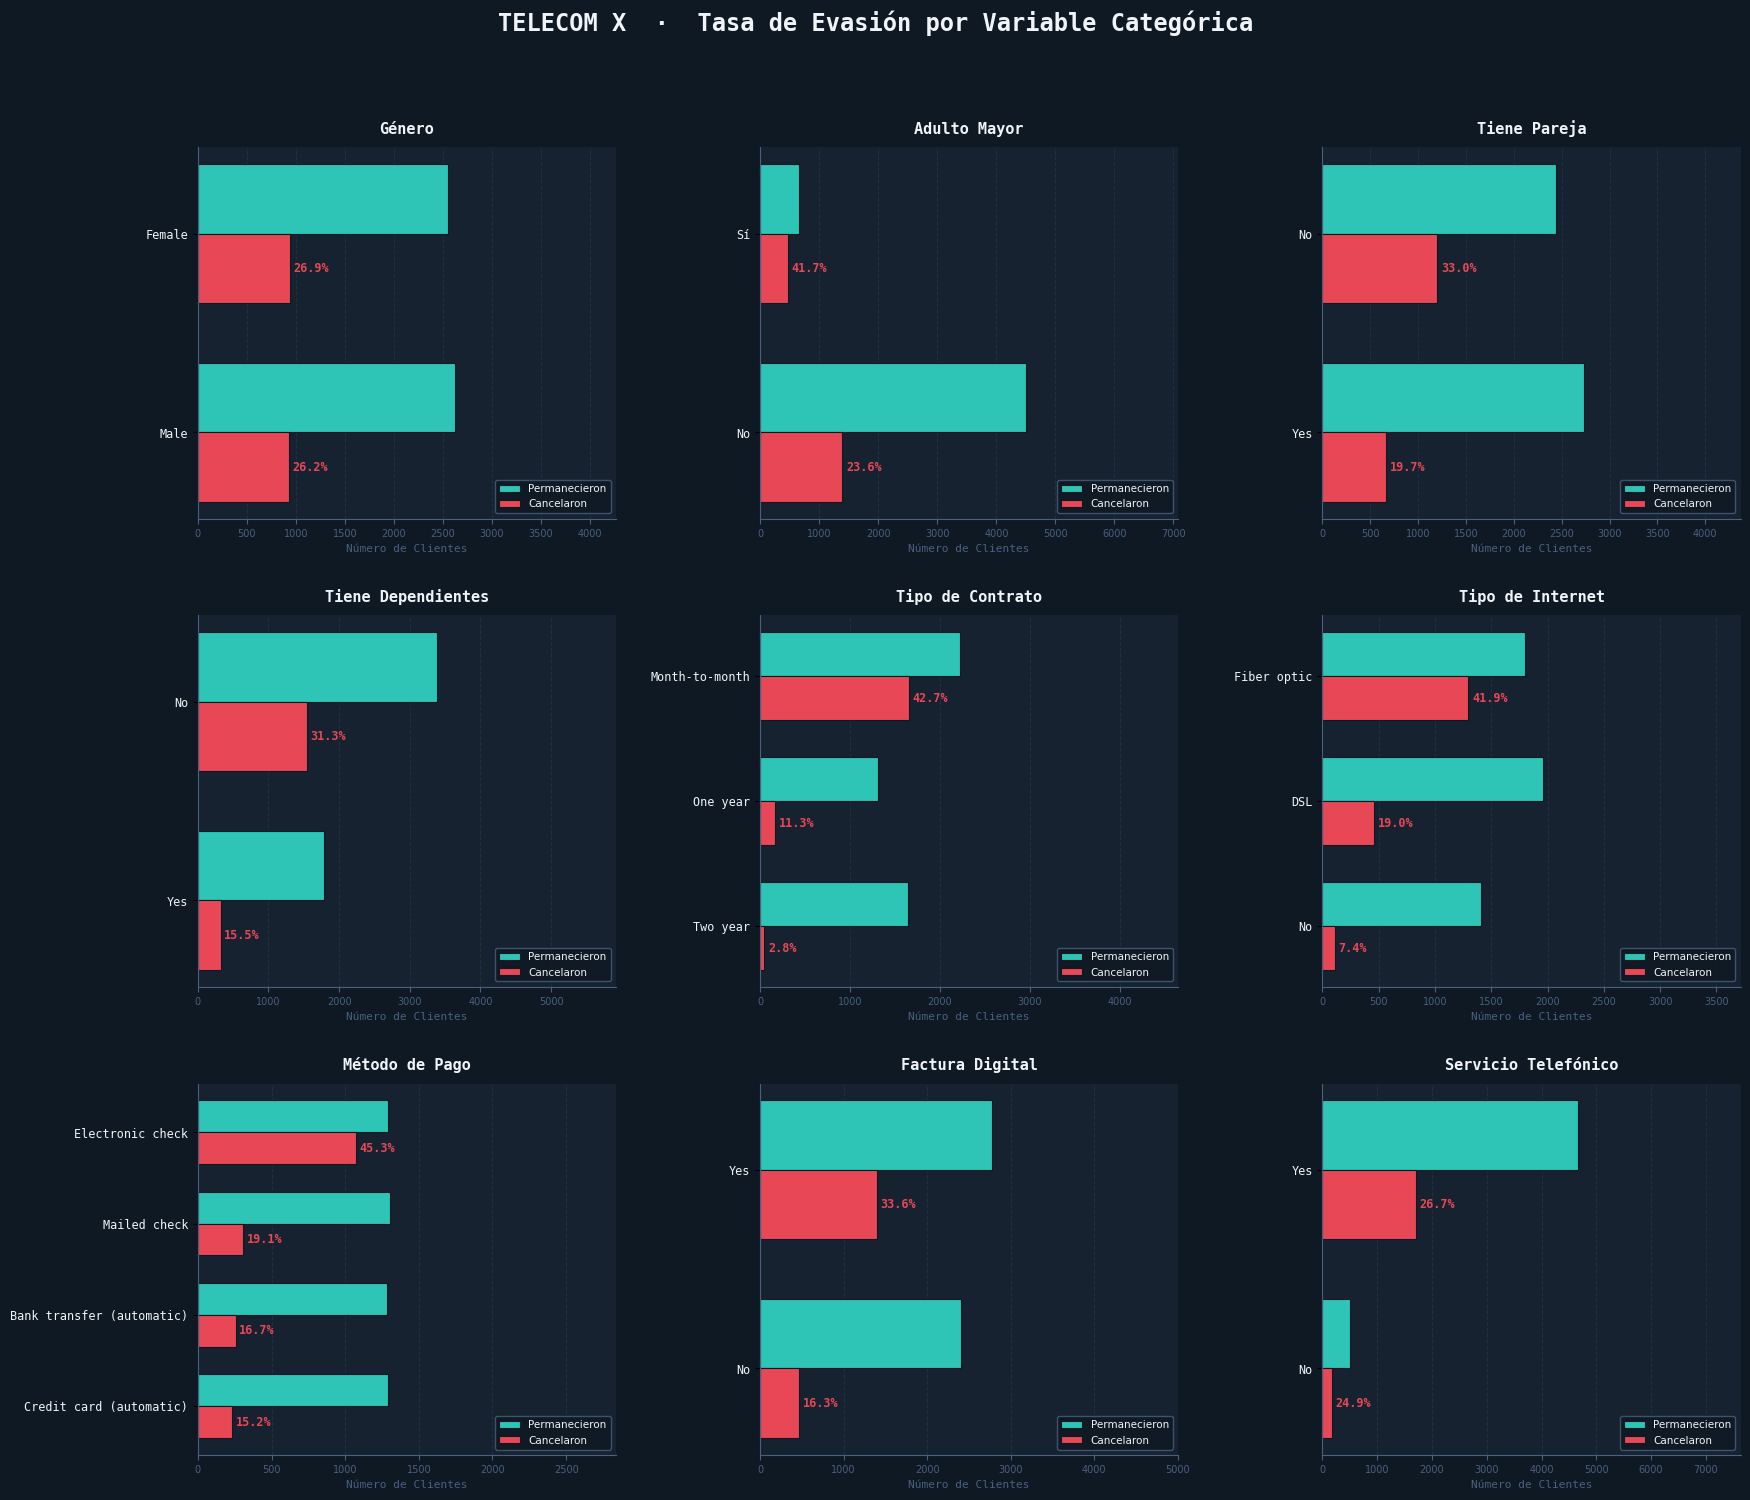

📊 RESUMEN: TASA DE CHURN POR VARIABLE CATEGÓRICA

📌 Género:
        Cancelaron  Total  tasa_%
genero                           
Female       939.0   3488    26.9
Male         930.0   3555    26.2

📌 Adulto Mayor:
              Cancelaron  Total  tasa_%
adulto_mayor                           
Sí                 476.0   1142    41.7
No                1393.0   5901    23.6

📌 Tiene Pareja:
              Cancelaron  Total  tasa_%
tiene_pareja                           
No                1200.0   3641    33.0
Yes                669.0   3402    19.7

📌 Tiene Dependientes:
                    Cancelaron  Total  tasa_%
tiene_dependientes                           
No                      1543.0   4933    31.3
Yes                      326.0   2110    15.5

📌 Tipo de Contrato:
                Cancelaron  Total  tasa_%
tipo_contrato                            
Month-to-month      1655.0   3875    42.7
One year             166.0   1473    11.3
Two year              48.0   1695     2.8

📌 Tipo de I

In [10]:
# ============================================================
# TELECOM X - Análisis de Evasión de Clientes
# Paso 8: Churn por Variables Categóricas
# ============================================================

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

# ── Cargar y preparar datos ───────────────────────────────────
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
response = requests.get(url)
data = response.json()
df = pd.json_normalize(data)

nuevos_nombres = {
    "customerID":                "id_cliente",
    "customer.gender":           "genero",
    "customer.SeniorCitizen":    "adulto_mayor",
    "customer.Partner":          "tiene_pareja",
    "customer.Dependents":       "tiene_dependientes",
    "customer.tenure":           "meses_contrato",
    "phone.PhoneService":        "servicio_telefono",
    "phone.MultipleLines":       "multiples_lineas",
    "internet.InternetService":  "tipo_internet",
    "internet.OnlineSecurity":   "seguridad_online",
    "internet.OnlineBackup":     "respaldo_online",
    "internet.DeviceProtection": "proteccion_dispositivo",
    "internet.TechSupport":      "soporte_tecnico",
    "internet.StreamingTV":      "streaming_tv",
    "internet.StreamingMovies":  "streaming_peliculas",
    "account.Contract":          "tipo_contrato",
    "account.PaperlessBilling":  "factura_digital",
    "account.PaymentMethod":     "metodo_pago",
    "account.Charges.Monthly":   "cargo_mensual",
    "account.Charges.Total":     "cargo_total",
    "Churn":                     "churn",
}
df_clean = df.rename(columns={k: v for k, v in nuevos_nombres.items() if k in df.columns})
df_clean["cargo_total"]   = pd.to_numeric(df_clean["cargo_total"], errors="coerce")
df_clean["cargo_mensual"] = pd.to_numeric(df_clean["cargo_mensual"], errors="coerce")
df_clean["cargo_total"]   = df_clean["cargo_total"].fillna(df_clean["cargo_total"].median())
df_clean["churn"]         = df_clean["churn"].map({"Yes": 1, "No": 0})
df_clean["adulto_mayor"]  = df_clean["adulto_mayor"].astype(str).map({"1": "Sí", "0": "No"})
df_clean.drop_duplicates(inplace=True)

# ── Paleta ────────────────────────────────────────────────────
COLOR_STAY  = "#2EC4B6"
COLOR_CHURN = "#E84855"
COLOR_BG    = "#0F1923"
COLOR_PANEL = "#162230"
COLOR_TEXT  = "#F0F4F8"
COLOR_SUB   = "#4A6080"

# ── Variables a analizar ──────────────────────────────────────
variables = [
    ("genero",               "Género"),
    ("adulto_mayor",         "Adulto Mayor"),
    ("tiene_pareja",         "Tiene Pareja"),
    ("tiene_dependientes",   "Tiene Dependientes"),
    ("tipo_contrato",        "Tipo de Contrato"),
    ("tipo_internet",        "Tipo de Internet"),
    ("metodo_pago",          "Método de Pago"),
    ("factura_digital",      "Factura Digital"),
    ("servicio_telefono",    "Servicio Telefónico"),
]
variables = [(col, label) for col, label in variables if col in df_clean.columns]

# ================================================================
# FIGURA: grilla de subgráficos por variable categórica
# ================================================================
ncols = 3
nrows = -(-len(variables) // ncols)   # ceil division

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(18, nrows * 5),
                         facecolor=COLOR_BG)
fig.suptitle(
    "TELECOM X  ·  Tasa de Evasión por Variable Categórica",
    fontsize=17, fontweight="bold", color=COLOR_TEXT,
    fontfamily="monospace", y=1.01
)
axes_flat = axes.flatten()

for idx, (col, titulo) in enumerate(variables):
    ax = axes_flat[idx]
    ax.set_facecolor(COLOR_PANEL)

    # Calcular conteos y tasa de churn por categoría
    grupo = df_clean.groupby(col)["churn"].agg(["sum", "count"]).reset_index()
    grupo.columns = [col, "cancelaron", "total"]
    grupo["tasa_churn"] = (grupo["cancelaron"] / grupo["total"] * 100).round(1)
    grupo["se_quedaron"] = grupo["total"] - grupo["cancelaron"]
    grupo = grupo.sort_values("tasa_churn", ascending=True)

    categorias = grupo[col].astype(str).tolist()
    y = np.arange(len(categorias))
    height = 0.35

    # Barras apiladas: se quedaron + cancelaron
    bars_stay  = ax.barh(y + height/2, grupo["se_quedaron"], height=height,
                         color=COLOR_STAY,  label="Permanecieron",
                         edgecolor=COLOR_BG, linewidth=0.8)
    bars_churn = ax.barh(y - height/2, grupo["cancelaron"],  height=height,
                         color=COLOR_CHURN, label="Cancelaron",
                         edgecolor=COLOR_BG, linewidth=0.8)

    # Etiqueta de tasa de churn al final de cada barra de cancelados
    for i, (bar, tasa) in enumerate(zip(bars_churn, grupo["tasa_churn"])):
        ax.text(bar.get_width() + grupo["total"].max() * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f"{tasa}%", va="center", ha="left",
                fontsize=8.5, fontweight="bold",
                color=COLOR_CHURN, fontfamily="monospace")

    ax.set_yticks(y)
    ax.set_yticklabels(categorias, fontsize=8.5,
                       color=COLOR_TEXT, fontfamily="monospace")
    ax.set_title(titulo, color=COLOR_TEXT, fontsize=11,
                 fontfamily="monospace", pad=10, fontweight="bold")
    ax.set_xlabel("Número de Clientes", color=COLOR_SUB,
                  fontsize=8, fontfamily="monospace")
    ax.tick_params(axis="x", colors=COLOR_SUB, labelsize=7)
    ax.spines[["top", "right", "left", "bottom"]].set_color(COLOR_SUB)
    ax.spines[["top", "right"]].set_visible(False)
    ax.xaxis.grid(True, color=COLOR_SUB, alpha=0.2, linestyle="--")
    ax.set_axisbelow(True)
    ax.set_xlim(0, grupo["total"].max() * 1.2)

    legend = ax.legend(fontsize=7.5, facecolor=COLOR_BG,
                       edgecolor=COLOR_SUB, labelcolor=COLOR_TEXT,
                       framealpha=0.8, loc="lower right")

# Ocultar ejes sobrantes
for idx in range(len(variables), len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.tight_layout(pad=2.5)
plt.savefig("telecomx_churn_categoricas.png", dpi=150,
            bbox_inches="tight", facecolor=COLOR_BG)
plt.show()

# ================================================================
# RESUMEN NUMÉRICO EN CONSOLA
# ================================================================
print("="*60)
print("📊 RESUMEN: TASA DE CHURN POR VARIABLE CATEGÓRICA")
print("="*60)

for col, titulo in variables:
    grupo = df_clean.groupby(col)["churn"].agg(["sum","count"])
    grupo["tasa_%"] = (grupo["sum"] / grupo["count"] * 100).round(1)
    grupo = grupo.rename(columns={"sum": "Cancelaron", "count": "Total"})
    print(f"\n📌 {titulo}:")
    print(grupo[["Cancelaron", "Total", "tasa_%"]].sort_values("tasa_%", ascending=False).to_string())

print("\n✅ Análisis por variables categóricas completado.")

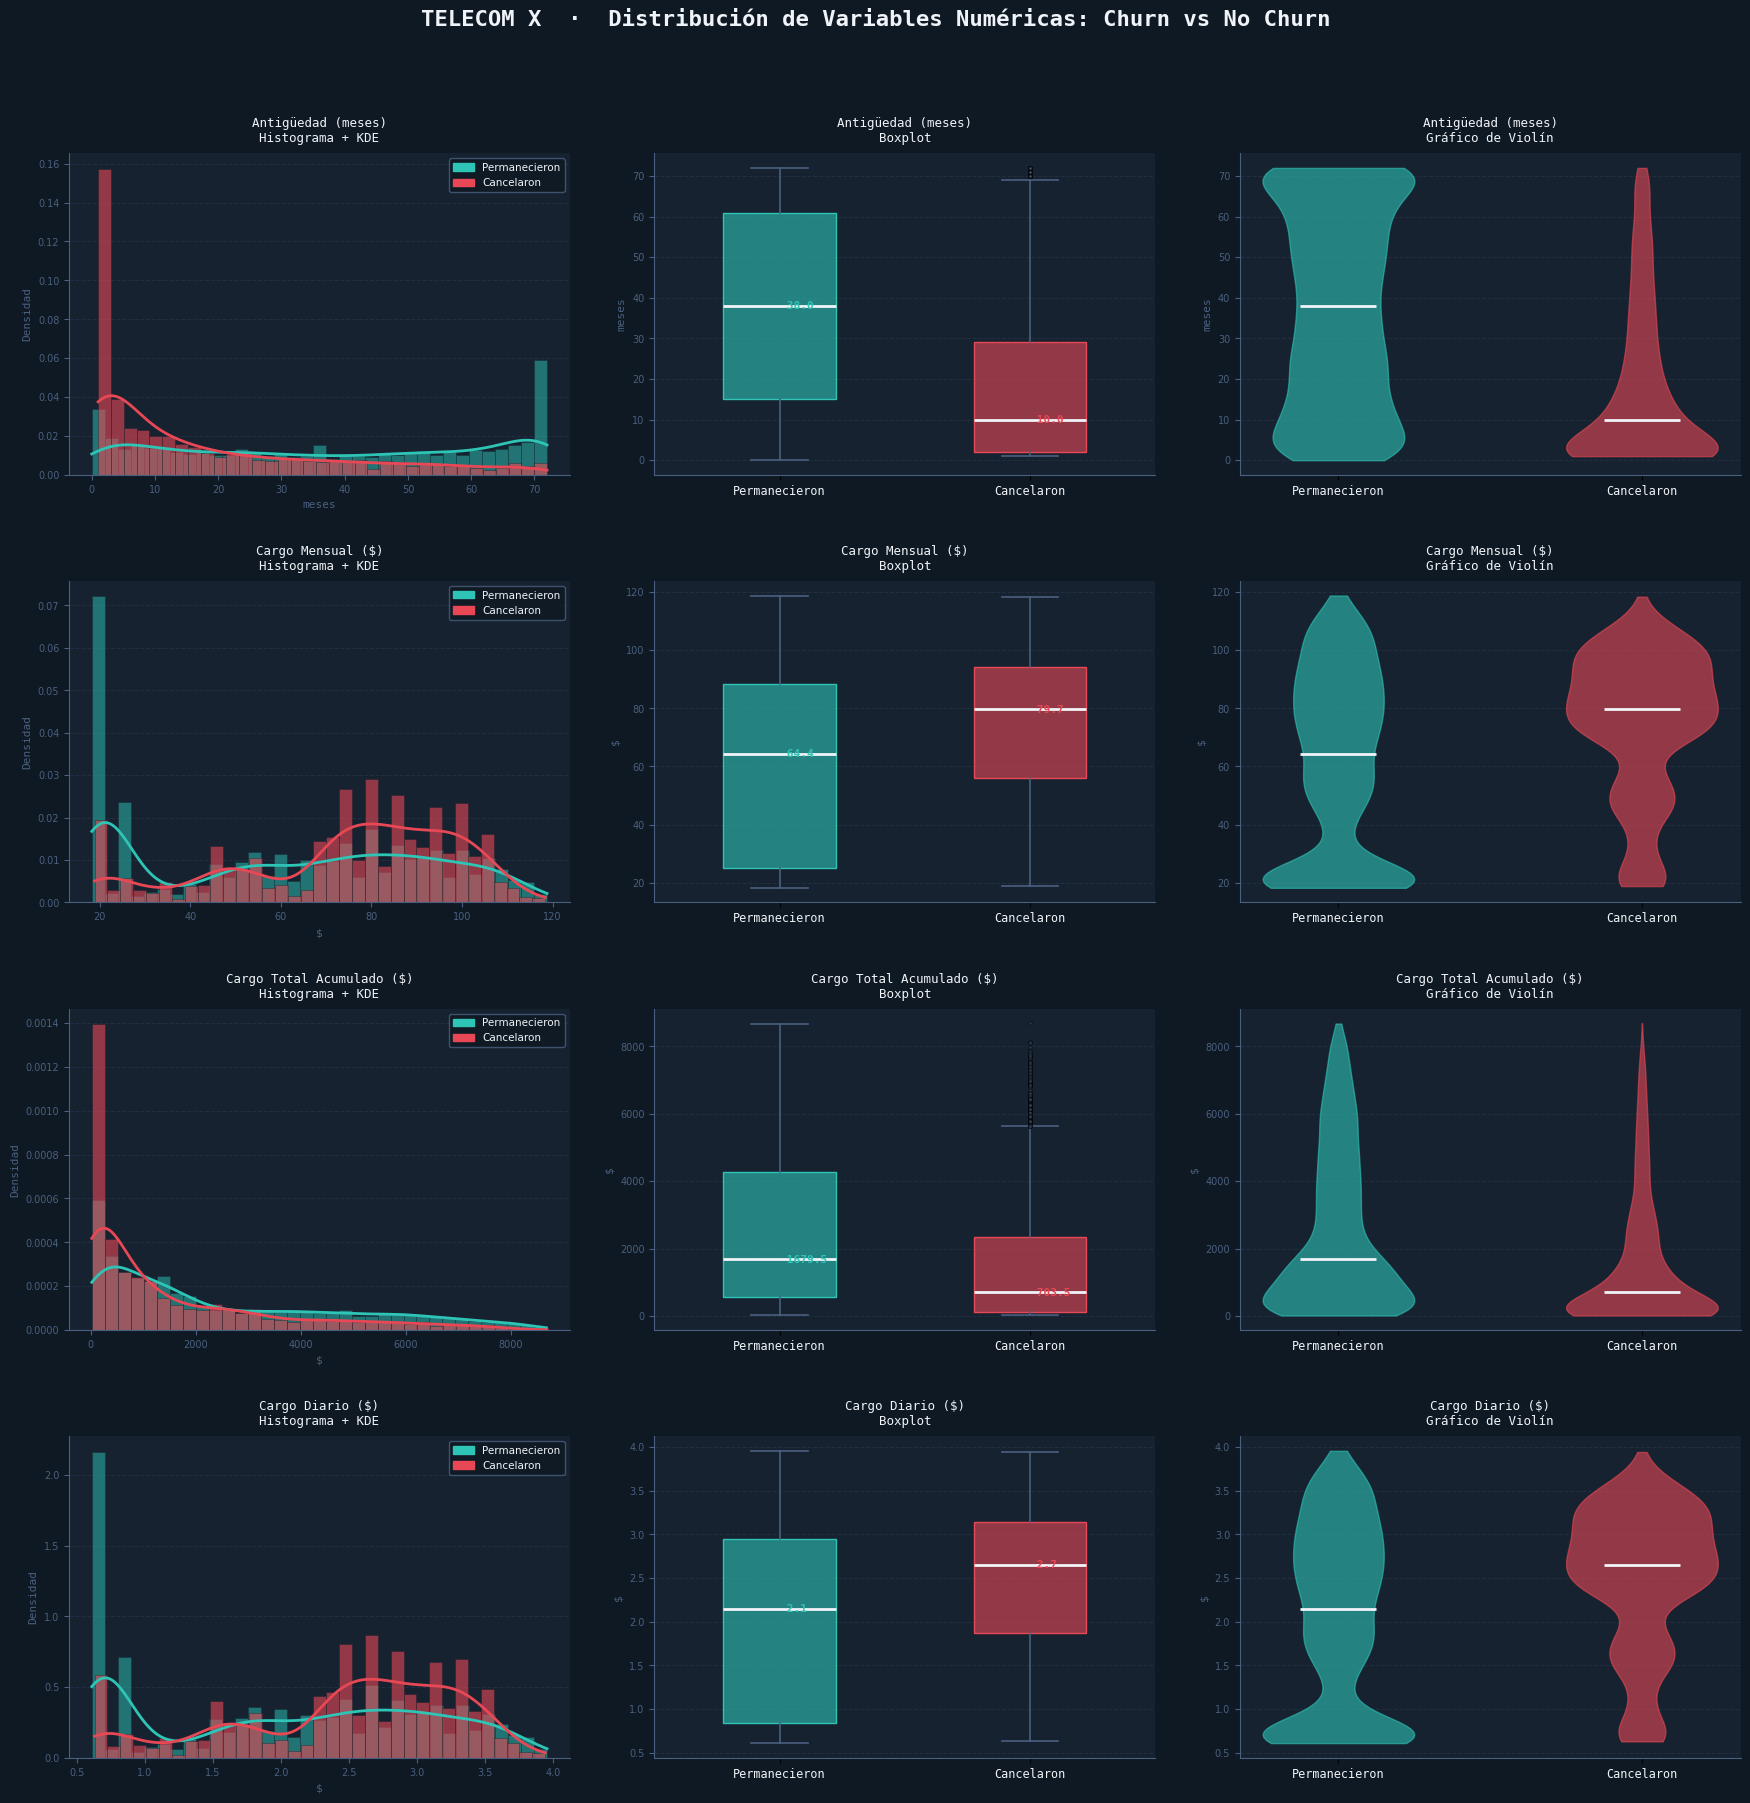

📊 RESUMEN ESTADÍSTICO: VARIABLES NUMÉRICAS POR CHURN

📌 Antigüedad (meses):
  Métrica               Permanecieron     Cancelaron
  --------------------------------------------------
  Media                       37.57          17.98
  Mediana                     38.00          10.00
  Desv. Estándar              24.11          19.53
  Mínimo                       0.00           1.00
  Máximo                      72.00          72.00
  Mann-Whitney U: p = 0.0000  →  ✅ Diferencia significativa (p < 0.05)

📌 Cargo Mensual ($):
  Métrica               Permanecieron     Cancelaron
  --------------------------------------------------
  Media                       61.27          74.44
  Mediana                     64.43          79.65
  Desv. Estándar              31.09          24.67
  Mínimo                      18.25          18.85
  Máximo                     118.75         118.35
  Mann-Whitney U: p = 0.0000  →  ✅ Diferencia significativa (p < 0.05)

📌 Cargo Total Acumulado ($):
  Métric

In [11]:
# ============================================================
# TELECOM X - Análisis de Evasión de Clientes
# Paso 9: Distribución de Variables Numéricas por Churn
# ============================================================

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from scipy import stats

# ── Cargar y preparar datos ───────────────────────────────────
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
response = requests.get(url)
data = response.json()
df = pd.json_normalize(data)

nuevos_nombres = {
    "customerID":                "id_cliente",
    "customer.gender":           "genero",
    "customer.SeniorCitizen":    "adulto_mayor",
    "customer.Partner":          "tiene_pareja",
    "customer.Dependents":       "tiene_dependientes",
    "customer.tenure":           "meses_contrato",
    "phone.PhoneService":        "servicio_telefono",
    "phone.MultipleLines":       "multiples_lineas",
    "internet.InternetService":  "tipo_internet",
    "internet.OnlineSecurity":   "seguridad_online",
    "internet.OnlineBackup":     "respaldo_online",
    "internet.DeviceProtection": "proteccion_dispositivo",
    "internet.TechSupport":      "soporte_tecnico",
    "internet.StreamingTV":      "streaming_tv",
    "internet.StreamingMovies":  "streaming_peliculas",
    "account.Contract":          "tipo_contrato",
    "account.PaperlessBilling":  "factura_digital",
    "account.PaymentMethod":     "metodo_pago",
    "account.Charges.Monthly":   "cargo_mensual",
    "account.Charges.Total":     "cargo_total",
    "Churn":                     "churn",
}
df_clean = df.rename(columns={k: v for k, v in nuevos_nombres.items() if k in df.columns})
df_clean["cargo_total"]      = pd.to_numeric(df_clean["cargo_total"], errors="coerce")
df_clean["cargo_mensual"]    = pd.to_numeric(df_clean["cargo_mensual"], errors="coerce")
df_clean["meses_contrato"]   = pd.to_numeric(df_clean["meses_contrato"], errors="coerce")
df_clean["cargo_total"]      = df_clean["cargo_total"].fillna(df_clean["cargo_total"].median())
df_clean["churn"]            = df_clean["churn"].map({"Yes": 1, "No": 0})
df_clean["Cuentas_Diarias"]  = (df_clean["cargo_mensual"] / 30).round(4)
df_clean.drop_duplicates(inplace=True)

# Separar grupos
churn_si = df_clean[df_clean["churn"] == 1]
churn_no = df_clean[df_clean["churn"] == 0]

# ── Paleta ────────────────────────────────────────────────────
COLOR_STAY  = "#2EC4B6"
COLOR_CHURN = "#E84855"
COLOR_BG    = "#0F1923"
COLOR_PANEL = "#162230"
COLOR_TEXT  = "#F0F4F8"
COLOR_SUB   = "#4A6080"

# ── Variables numéricas a analizar ────────────────────────────
variables = [
    ("meses_contrato",  "Antigüedad (meses)",       "meses"),
    ("cargo_mensual",   "Cargo Mensual ($)",         "$"),
    ("cargo_total",     "Cargo Total Acumulado ($)", "$"),
    ("Cuentas_Diarias", "Cargo Diario ($)",          "$"),
]
variables = [(col, label, unit) for col, label, unit in variables
             if col in df_clean.columns]

# ================================================================
# FIGURA: 3 tipos de gráfico por cada variable numérica
# Columnas: Histograma+KDE | Boxplot | Violín
# ================================================================
nrows = len(variables)
ncols = 3

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(18, nrows * 4.5),
                         facecolor=COLOR_BG)
fig.suptitle(
    "TELECOM X  ·  Distribución de Variables Numéricas: Churn vs No Churn",
    fontsize=16, fontweight="bold", color=COLOR_TEXT,
    fontfamily="monospace", y=1.01
)

legend_patch = [
    mpatches.Patch(color=COLOR_STAY,  label="Permanecieron"),
    mpatches.Patch(color=COLOR_CHURN, label="Cancelaron"),
]

for row, (col, label, unit) in enumerate(variables):
    data_no = churn_no[col].dropna()
    data_si = churn_si[col].dropna()

    # ── Col 0: Histograma + KDE ───────────────────────────────
    ax0 = axes[row, 0]
    ax0.set_facecolor(COLOR_PANEL)

    bins = 35
    ax0.hist(data_no, bins=bins, color=COLOR_STAY,  alpha=0.5,
             density=True, label="Permanecieron", edgecolor=COLOR_BG, linewidth=0.4)
    ax0.hist(data_si, bins=bins, color=COLOR_CHURN, alpha=0.6,
             density=True, label="Cancelaron",    edgecolor=COLOR_BG, linewidth=0.4)

    # KDE suavizado
    for data_grp, color in [(data_no, COLOR_STAY), (data_si, COLOR_CHURN)]:
        if len(data_grp) > 1:
            kde = stats.gaussian_kde(data_grp)
            x_range = np.linspace(data_grp.min(), data_grp.max(), 300)
            ax0.plot(x_range, kde(x_range), color=color, linewidth=2)

    ax0.set_title(f"{label}\nHistograma + KDE", color=COLOR_TEXT,
                  fontsize=9, fontfamily="monospace", pad=8)
    ax0.set_xlabel(unit, color=COLOR_SUB, fontsize=8, fontfamily="monospace")
    ax0.set_ylabel("Densidad",  color=COLOR_SUB, fontsize=8, fontfamily="monospace")
    ax0.tick_params(colors=COLOR_SUB, labelsize=7)
    ax0.spines[["top","right"]].set_visible(False)
    ax0.spines[["left","bottom"]].set_color(COLOR_SUB)
    ax0.yaxis.grid(True, color=COLOR_SUB, alpha=0.2, linestyle="--")
    ax0.set_axisbelow(True)
    ax0.legend(handles=legend_patch, fontsize=7.5,
               facecolor=COLOR_BG, edgecolor=COLOR_SUB,
               labelcolor=COLOR_TEXT, framealpha=0.8)

    # ── Col 1: Boxplot ────────────────────────────────────────
    ax1 = axes[row, 1]
    ax1.set_facecolor(COLOR_PANEL)

    bp = ax1.boxplot(
        [data_no, data_si],
        patch_artist=True,
        widths=0.45,
        medianprops=dict(color=COLOR_TEXT, linewidth=2),
        whiskerprops=dict(color=COLOR_SUB, linewidth=1.2),
        capprops=dict(color=COLOR_SUB, linewidth=1.2),
        flierprops=dict(marker="o", markersize=2.5,
                        markerfacecolor=COLOR_SUB, alpha=0.4,
                        linestyle="none"),
    )
    bp["boxes"][0].set_facecolor(COLOR_STAY  + "99")  # alpha hex
    bp["boxes"][1].set_facecolor(COLOR_CHURN + "99")
    bp["boxes"][0].set_edgecolor(COLOR_STAY)
    bp["boxes"][1].set_edgecolor(COLOR_CHURN)

    # Anotaciones de mediana
    for i, (data_grp, color) in enumerate([(data_no, COLOR_STAY), (data_si, COLOR_CHURN)], 1):
        med = data_grp.median()
        ax1.text(i, med, f" {med:.1f}", va="center", ha="left",
                 fontsize=8, color=color, fontfamily="monospace",
                 fontweight="bold")

    ax1.set_xticklabels(["Permanecieron", "Cancelaron"],
                        color=COLOR_TEXT, fontsize=8.5, fontfamily="monospace")
    ax1.set_title(f"{label}\nBoxplot", color=COLOR_TEXT,
                  fontsize=9, fontfamily="monospace", pad=8)
    ax1.set_ylabel(unit, color=COLOR_SUB, fontsize=8, fontfamily="monospace")
    ax1.tick_params(axis="y", colors=COLOR_SUB, labelsize=7)
    ax1.spines[["top","right"]].set_visible(False)
    ax1.spines[["left","bottom"]].set_color(COLOR_SUB)
    ax1.yaxis.grid(True, color=COLOR_SUB, alpha=0.2, linestyle="--")
    ax1.set_axisbelow(True)

    # ── Col 2: Gráfico de violín ──────────────────────────────
    ax2 = axes[row, 2]
    ax2.set_facecolor(COLOR_PANEL)

    parts = ax2.violinplot(
        [data_no, data_si],
        positions=[1, 2],
        showmedians=True,
        showextrema=False,
    )
    colors_violin = [COLOR_STAY, COLOR_CHURN]
    for pc, color in zip(parts["bodies"], colors_violin):
        pc.set_facecolor(color)
        pc.set_edgecolor(color)
        pc.set_alpha(0.6)
    parts["cmedians"].set_color(COLOR_TEXT)
    parts["cmedians"].set_linewidth(2)

    ax2.set_xticks([1, 2])
    ax2.set_xticklabels(["Permanecieron", "Cancelaron"],
                        color=COLOR_TEXT, fontsize=8.5, fontfamily="monospace")
    ax2.set_title(f"{label}\nGráfico de Violín", color=COLOR_TEXT,
                  fontsize=9, fontfamily="monospace", pad=8)
    ax2.set_ylabel(unit, color=COLOR_SUB, fontsize=8, fontfamily="monospace")
    ax2.tick_params(axis="y", colors=COLOR_SUB, labelsize=7)
    ax2.spines[["top","right"]].set_visible(False)
    ax2.spines[["left","bottom"]].set_color(COLOR_SUB)
    ax2.yaxis.grid(True, color=COLOR_SUB, alpha=0.2, linestyle="--")
    ax2.set_axisbelow(True)

plt.tight_layout(pad=2.5)
plt.savefig("telecomx_churn_numericas.png", dpi=150,
            bbox_inches="tight", facecolor=COLOR_BG)
plt.show()

# ================================================================
# RESUMEN ESTADÍSTICO EN CONSOLA
# ================================================================
print("="*65)
print("📊 RESUMEN ESTADÍSTICO: VARIABLES NUMÉRICAS POR CHURN")
print("="*65)

for col, label, unit in variables:
    d_no = churn_no[col].dropna()
    d_si = churn_si[col].dropna()
    print(f"\n📌 {label}:")
    print(f"  {'Métrica':<18} {'Permanecieron':>16} {'Cancelaron':>14}")
    print(f"  {'-'*50}")
    print(f"  {'Media':<18} {d_no.mean():>14.2f}   {d_si.mean():>12.2f}")
    print(f"  {'Mediana':<18} {d_no.median():>14.2f}   {d_si.median():>12.2f}")
    print(f"  {'Desv. Estándar':<18} {d_no.std():>14.2f}   {d_si.std():>12.2f}")
    print(f"  {'Mínimo':<18} {d_no.min():>14.2f}   {d_si.min():>12.2f}")
    print(f"  {'Máximo':<18} {d_no.max():>14.2f}   {d_si.max():>12.2f}")

    # Test de Mann-Whitney para significancia estadística
    stat, p = stats.mannwhitneyu(d_no, d_si, alternative="two-sided")
    sig = "✅ Diferencia significativa (p < 0.05)" if p < 0.05 else "⚠️  Sin diferencia significativa"
    print(f"  Mann-Whitney U: p = {p:.4f}  →  {sig}")

print("\n✅ Análisis de variables numéricas completado.")

# 📄 Informe Final: Análisis de Evasión de Clientes (Churn) en Telecom X

## 🔹 Introducción

El presente informe detalla el análisis de evasión de clientes (Churn) para la empresa **Telecom X**. El objetivo principal es identificar los factores clave que influyen en la decisión de los clientes de cancelar sus servicios, con el fin de desarrollar estrategias efectivas de retención. La evasión de clientes es un problema crítico para las empresas de telecomunicaciones, ya que la adquisición de nuevos clientes es significativamente más costosa que la retención de los existentes. Comprender y predecir el churn permite a Telecom X actuar proactivamente para mantener su base de clientes y asegurar la sostenibilidad del negocio.

### 🔹 Limpieza y Tratamiento de Datos

El proceso de preparación de datos incluyó los siguientes pasos:

1.  **Carga de Datos**: Los datos se cargaron directamente desde un archivo JSON a través de una URL, y se transformaron en un DataFrame de Pandas para su manipulación.

2.  **Exploración Inicial**: Se realizó una revisión de dimensiones, tipos de datos y los primeros registros para obtener una visión general del dataset.

3.  **Renombrado de Columnas**: Las columnas con nombres jerárquicos (ej. `customer.gender`) se renombraron a un formato más simple y legible (ej. `genero`) para facilitar el análisis.

4.  **Manejo de Valores Ausentes y Errores**: Se identificaron y trataron valores nulos, específicamente en la columna `account.Charges.Total` (renombrada a `cargo_total`), que contenía strings vacíos. Estos se convirtieron a numéricos y los valores resultantes nulos se imputaron con la mediana. También se identificaron 224 valores nulos en la columna `churn`.

5.  **Conversión de Tipos de Datos**: Las columnas como `cargo_total`, `cargo_mensual` y `meses_contrato` se aseguraron como numéricas. La variable objetivo `churn` se convirtió de `Yes`/`No` a `1`/`0` para el análisis cuantitativo.

6.  **Estandarización de Strings**: Se eliminaron espacios en blanco al inicio y final de todas las columnas de texto para evitar inconsistencias.

7.  **Creación de Nuevas Características**: Se creó la columna `Cuentas_Diarias` (cargo mensual / 30) para un análisis más granular del costo diario por cliente.

El dataset final, `df_clean`, quedó con 7267 filas y 22 columnas, listo para el análisis exploratorio. Se identificaron 224 valores nulos restantes en la columna `churn`.

## 🔹 Análisis Exploratorio de Datos (EDA)

El EDA se centró en entender la distribución de las variables y su relación con la tasa de evasión (churn). Los principales hallazgos se resumen a continuación:

### 📊 Tasa General de Churn

Se identificó una **tasa de evasión del 25.72%**, lo que significa que aproximadamente uno de cada cuatro clientes de Telecom X cancela sus servicios. Esto representa una base significativa de clientes perdidos que requiere atención. (Ver gráfico en `telecomx_churn_distribucion.png`).

### 📈 Variables Numéricas

Se analizaron `meses_contrato`, `cargo_mensual`, `cargo_total` y `Cuentas_Diarias` en relación con el churn. Los resultados muestran:

*   **Antigüedad (`meses_contrato`)**: Los clientes que cancelan tienen una antigüedad promedio significativamente menor (17.98 meses) en comparación con los que permanecen (37.57 meses). Esto sugiere que los clientes con menor antigüedad son más propensos a la evasión. (Ver `telecomx_churn_numericas.png`).
*   **Cargo Mensual (`cargo_mensual`) y Cargo Diario (`Cuentas_Diarias`)**: Los clientes que cancelan tienen un cargo mensual y diario promedio más alto ($74.44 y $2.48, respectivamente) que los que no cancelan ($61.27 y $2.04). Esto indica que un mayor gasto mensual podría ser un factor de insatisfacción o percepción de poco valor por el precio. (Ver `telecomx_churn_numericas.png`).
*   **Cargo Total (`cargo_total`)**: Los clientes que cancelan tienen un cargo total acumulado menor, lo cual es coherente con su menor antigüedad. (Ver `telecomx_churn_numericas.png`).

###  Variables Categóricas

El análisis de variables categóricas reveló patrones importantes en la tasa de churn:

*   **Tipo de Contrato**: Los clientes con contratos **mes a mes** presentan una tasa de evasión alarmantemente alta (42.7%), muy superior a los contratos de un año (11.3%) y dos años (2.8%). Esto subraya la importancia de los contratos a largo plazo para la retención. (Ver `telecomx_churn_categoricas.png`).
*   **Tipo de Internet**: Los clientes con servicio de **fibra óptica** tienen una tasa de churn considerablemente más alta (41.9%) que aquellos con DSL (19.0%) o sin servicio de internet (7.4%). Esto podría indicar problemas con la calidad o el costo del servicio de fibra óptica.
*   **Método de Pago**: El **cheque electrónico** está asociado con la tasa de churn más alta (45.3%), mientras que los métodos de pago automático (transferencia bancaria, tarjeta de crédito) tienen tasas de evasión mucho más bajas (16.7% y 15.2%, respectivamente).
*   **Factura Digital**: Los clientes que reciben **factura digital** tienen una tasa de churn más alta (33.6%) que los que no (16.3%).
*   **Adulto Mayor**: Los **adultos mayores** tienen una tasa de churn casi el doble (41.7%) que los no adultos mayores (23.6%), lo que podría sugerir necesidades no satisfechas en este segmento.
*   **Género, Pareja, Dependientes, Servicio Telefónico**: Estas variables mostraron diferencias menos pronunciadas en las tasas de churn (Ver `telecomx_churn_categoricas.png`).

### 🎯 Correlaciones

Las correlaciones más fuertes con el churn fueron:

*   **Correlación Negativa**: `meses_contrato` (r = -0.352) y `cargo_total` (r = -0.199). Esto confirma que a menor antigüedad y menor cargo total, mayor la probabilidad de churn.
*   **Correlación Positiva**: `cargo_mensual` (r = 0.193) y `Cuentas_Diarias` (r = 0.193). Un mayor cargo mensual/diario se asocia con mayor churn.

## 🔹 Conclusiones e Insights

Los hallazgos del análisis de datos revelan patrones claros sobre la evasión de clientes en Telecom X:

1.  **Antigüedad Crítica**: Los clientes nuevos o con poca antigüedad son el grupo de mayor riesgo. Esto sugiere que el periodo inicial de la relación con el cliente es crucial y se deben fortalecer las estrategias de bienvenida y fidelización temprana.

2.  **Costos y Percepción de Valor**: Clientes con cargos mensuales y diarios más altos son más propensos a cancelar. Esto puede indicar una falta de satisfacción con el valor recibido por el precio pagado, o que la competencia ofrece mejores tarifas para paquetes similares.

3.  **Impacto del Contrato a Largo Plazo**: La duración del contrato es un predictor muy fuerte de la retención. Los clientes con contratos anuales o bianuales son significativamente más leales, mientras que los de mes a mes son altamente volátiles.

4.  **Servicios Específicos Problemáticos**: El servicio de **fibra óptica** y la **facturación digital** muestran tasas de churn elevadas. Esto podría apuntar a problemas de calidad de servicio o soporte para la fibra óptica, y quizás una falta de entendimiento o valor percibido en la factura digital. El **cheque electrónico** como método de pago también está ligado a un churn alto, posiblemente por una menor automatización o fricción en el proceso de pago.

5.  **Segmentos Vulnerables**: Los **adultos mayores** representan un segmento con una tasa de evasión considerablemente más alta. Podrían tener necesidades específicas (ej. soporte técnico más personalizado, interfaces más sencillas) que no están siendo atendidas.

## 🔹 Recomendaciones Estratégicas

Basado en los insights obtenidos, se proponen las siguientes recomendaciones para Telecom X:

1.  **Programas de Retención Temprana**: Implementar programas proactivos de seguimiento y fidelización para clientes nuevos, especialmente durante sus primeros 12-18 meses de contrato. Esto podría incluir llamadas de cortesía, ofertas personalizadas, o mejoras de servicio.

2.  **Optimización de Planes de Fibra Óptica**: Investigar las causas del alto churn en clientes de fibra óptica. Podría ser necesario mejorar la calidad del servicio, la estabilidad de la conexión, el soporte técnico, o ajustar los precios para ser más competitivos.

3.  **Incentivos para Contratos a Largo Plazo**: Ofrecer descuentos atractivos o beneficios adicionales para incentivar a los clientes de mes a mes a migrar a contratos de uno o dos años. Comunicar claramente el valor y los ahorros a largo plazo.

4.  **Promoción de Métodos de Pago Automáticos**: Educar a los clientes sobre los beneficios de los métodos de pago automáticos (transferencia bancaria, tarjeta de crédito) y ofrecer incentivos para que cambien de cheque electrónico a estas opciones. Esto reduce la fricción y puede mejorar la retención.

5.  **Mejora de la Experiencia del Adulto Mayor**: Desarrollar servicios y soporte específicos para el segmento de adultos mayores, como líneas de atención dedicadas, tutoriales simplificados, o asistencia técnica a domicilio. Esto podría abordar sus necesidades únicas y mejorar su satisfacción.

6.  **Revisión del Proceso de Facturación Digital**: Analizar el feedback de clientes sobre la factura digital. Es posible que se necesiten mejoras en la claridad del formato, el acceso a la información o la facilidad de gestión para reducir la evasión asociada.